# Data briefing - Exhibit 1: Customer portfolio

*All reported numbers are rounded to two decimal places.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")   # 2 decimal places everywhere

DATA = "../../data"
C = ["#4C72B0", "#DD8452", "#55A868"]   # HB, GB, LB

slp = pd.read_csv(f"{DATA}/slp_profiles.csv")

# Build local time from timestamp_utc (timestamp_local has changing UTC offsets)
t_local = pd.to_datetime(slp["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")
slp["hour"]       = t_local.dt.hour
slp["weekday"]    = t_local.dt.weekday          # Monday = 0 ... Sunday = 6
slp["is_weekend"] = slp["weekday"] >= 5
slp["month"]      = t_local.dt.month

print("shape:", slp.shape, " -> 366 days x 96 quarter-hours =", 366*96)
print("missing values:", int(slp[["hb_normalized_kwh","gb_normalized_kwh","lb_normalized_kwh"]].isna().sum().sum()))
slp.head()

shape: (35136, 9)  -> 366 days x 96 quarter-hours = 35136
missing values: 0


,timestamp_utc,timestamp_local,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh,hour,weekday,is_weekend,month
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,27.11,15.71,17.03,0,0,False,1
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,25.13,15.16,16.45,0,0,False,1
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,23.24,14.64,16.03,0,0,False,1
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,21.41,14.16,15.71,0,0,False,1
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,19.64,13.74,15.48,1,0,False,1


## 1. Annual energy by customer group  ($E_p = n_p \cdot e_p$)

Values from the customer table (Data Description, section 2).

In [2]:
customers = pd.DataFrame(
    {"n": [10_000, 200, 20], "e_mwh_per_customer": [3.5, 30.0, 100.0]},
    index=["HB", "GB", "LB"],
)
customers["E_MWh"]     = customers["n"] * customers["e_mwh_per_customer"]
customers["share_pct"] = 100 * customers["E_MWh"] / customers["E_MWh"].sum()

print(f"Annual portfolio energy: {customers['E_MWh'].sum():,.2f} MWh")
customers

Annual portfolio energy: 43,000.00 MWh


,n,e_mwh_per_customer,E_MWh,share_pct
HB,10000,3.50,"35,000.00",81.40
GB,200,30.00,"6,000.00",13.95
LB,20,100.00,"2,000.00",4.65


## 2. Scaling the standard load profiles

Each `*_normalized_kwh` column describes only the **shape** of consumption; by construction its
annual sum is 1,000,000 kWh. A single factor per profile lifts the curve to the required annual
energy without changing its time shape:

$$L_{p,t} = E_p \cdot \frac{s_{p,t}}{\sum_\tau s_{p,\tau}}$$

In [3]:
col = {"HB": "hb_normalized_kwh", "GB": "gb_normalized_kwh", "LB": "lb_normalized_kwh"}

annual_norm_kwh = {g: slp[c].sum() for g, c in col.items()}
print("annual sum of normalized profile [kWh]:", {g: round(v, 2) for g, v in annual_norm_kwh.items()})

# effective scaling factor (normalized kWh -> portfolio kWh)
factor = {g: customers.loc[g, "E_MWh"] * 1_000 / annual_norm_kwh[g] for g in col}
print("scaling factor:", {g: round(v, 2) for g, v in factor.items()})

load = pd.DataFrame(index=slp.index)
for g, c in col.items():
    load[g] = customers.loc[g, "E_MWh"] * slp[c] / slp[c].sum()   # MWh per quarter-hour
load["total"] = load[["HB", "GB", "LB"]].sum(axis=1)

for k in ["hour", "weekday", "is_weekend", "month"]:
    load[k] = slp[k]

load[["HB", "GB", "LB", "total"]].describe()

annual sum of normalized profile [kWh]: {'HB': 1000000.0, 'GB': 1000000.0, 'LB': 1000000.0}
scaling factor: {'HB': 35.0, 'GB': 6.0, 'LB': 2.0}


,HB,GB,LB,total
count,"35,136.00","35,136.00","35,136.00","35,136.00"
mean,1.00,0.17,0.06,1.22
std,0.43,0.09,0.02,0.49
min,0.32,0.06,0.02,0.42
25%,0.60,0.10,0.03,0.74
50%,1.04,0.13,0.05,1.31
75%,1.27,0.26,0.07,1.57
max,2.34,0.36,0.12,2.60


## 3. Reconciliation with the customer assumptions

$\sum_t L_{p,t}$ must equal $E_p$ exactly.

In [4]:
check = pd.DataFrame({
    "E_target_MWh": customers["E_MWh"],
    "sum_L_MWh":    [load["HB"].sum(), load["GB"].sum(), load["LB"].sum()],
})
check["diff"] = check["sum_L_MWh"] - check["E_target_MWh"]
check.loc["Total"] = check.sum()

assert np.allclose(check.loc[["HB", "GB", "LB"], "diff"], 0, atol=1e-6)
print("Reconciliation ok - annual energy matches the customer table exactly.")
print(f"Average portfolio power: {load['total'].sum() / (366*24):,.2f} MW")
print(f"Total load range: {load['total'].min()*4:,.2f} - {load['total'].max()*4:,.2f} MW")
check

Reconciliation ok - annual energy matches the customer table exactly.
Average portfolio power: 4.90 MW
Total load range: 1.68 - 10.40 MW


,E_target_MWh,sum_L_MWh,diff
HB,"35,000.00","35,000.00",0.00
GB,"6,000.00","6,000.00",-0.00
LB,"2,000.00","2,000.00",0.00
Total,"43,000.00","43,000.00",-0.00


## Visual A - annual energy and share by group

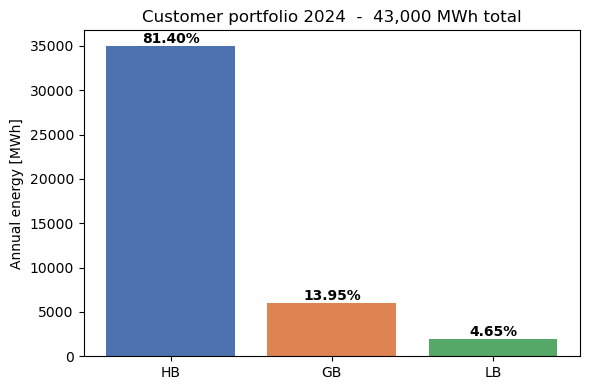

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(customers.index, customers["E_MWh"], color=C)
for b, s in zip(bars, customers["share_pct"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{s:.2f}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Annual energy [MWh]")
ax.set_title("Customer portfolio 2024  -  43,000 MWh total")
plt.tight_layout(); plt.show()

## Visual B - average daily shape

Mean per hour over the whole year. Left: absolute in MW (shows the composition).
Right: normalized to each group's daily mean (makes the shapes comparable).

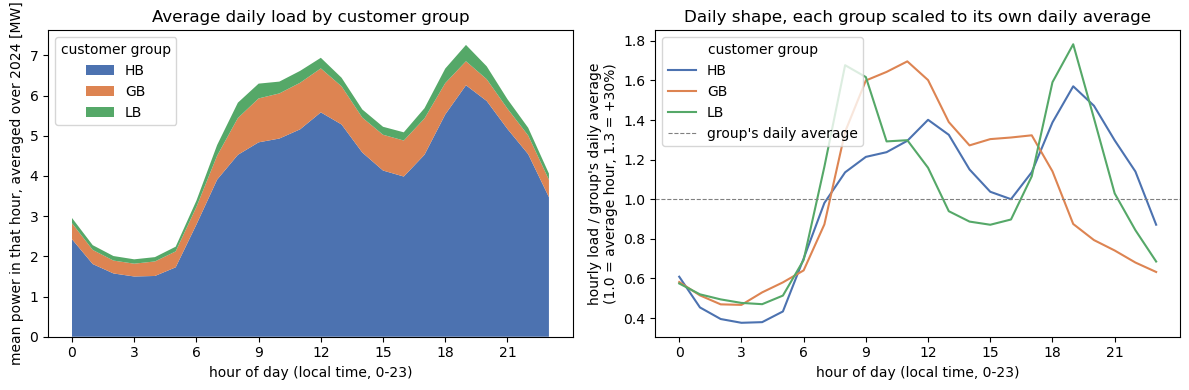

,HB,GB,LB,total
hour,,,,
0,2.43,0.40,0.13,2.95
1,1.81,0.35,0.12,2.28
2,1.57,0.32,0.11,2.01
3,1.50,0.32,0.11,1.93
4,1.51,0.36,0.11,1.98
5,1.73,0.40,0.12,2.24
6,2.79,0.44,0.16,3.39
7,3.91,0.60,0.27,4.77
8,4.53,0.92,0.38,5.82


In [6]:
hourly = load.groupby("hour")[["HB", "GB", "LB", "total"]].mean() * 4   # MWh/qh -> MW

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: absolute, stacked -> shows composition
axes[0].stackplot(hourly.index, hourly["HB"], hourly["GB"], hourly["LB"],
                  labels=["HB", "GB", "LB"], colors=C)
axes[0].set_title("Average daily load by customer group")
axes[0].set_xlabel("hour of day (local time, 0-23)")
axes[0].set_ylabel("mean power in that hour, averaged over 2024 [MW]")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(loc="upper left", title="customer group")

# right: each group divided by its own daily-average power -> shapes comparable
for g, c in zip(["HB", "GB", "LB"], C):
    axes[1].plot(hourly.index, hourly[g] / hourly[g].mean(), label=g, color=c)
axes[1].axhline(1, color="grey", lw=0.8, ls="--", label="group's daily average")
axes[1].set_title("Daily shape, each group scaled to its own daily average")
axes[1].set_xlabel("hour of day (local time, 0-23)")
axes[1].set_ylabel("hourly load / group's daily average\n(1.0 = average hour, 1.3 = +30%)")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(title="customer group")

plt.tight_layout(); plt.show()

hourly.round(2)

## Visual C - weekday vs. weekend

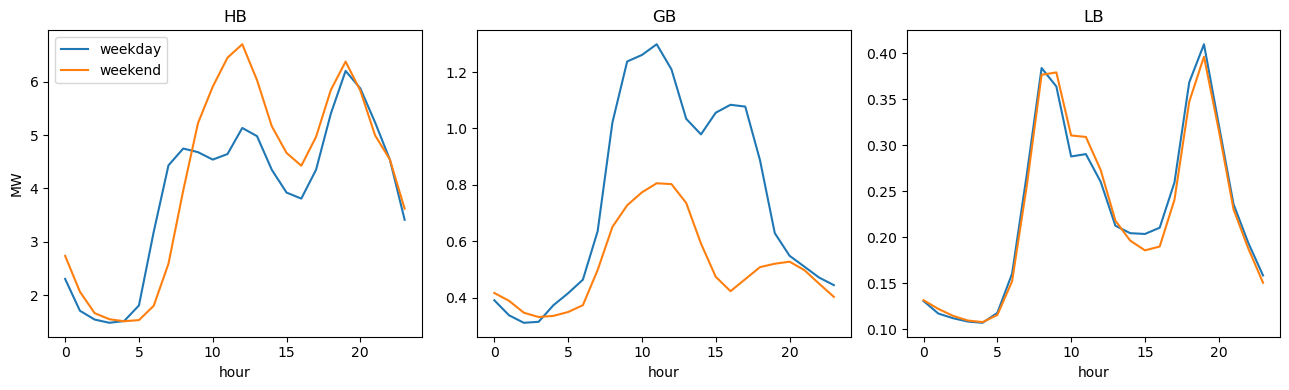

,HB,GB,LB,total
weekday,3.91,0.75,0.23,4.89
weekend,4.17,0.52,0.23,4.92


In [7]:
prof = load.groupby(["is_weekend", "hour"])[["HB", "GB", "LB"]].mean() * 4

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, g in zip(axes, ["HB", "GB", "LB"]):
    ax.plot(prof.loc[False].index, prof.loc[False][g], label="weekday")
    ax.plot(prof.loc[True].index,  prof.loc[True][g],  label="weekend")
    ax.set_title(g); ax.set_xlabel("hour")
axes[0].set_ylabel("MW"); axes[0].legend()
plt.tight_layout(); plt.show()

wk = load.groupby("is_weekend")[["HB", "GB", "LB", "total"]].mean() * 4
wk.index = ["weekday", "weekend"]
wk.round(2)

## Seasonal profile (context for Stage 3)

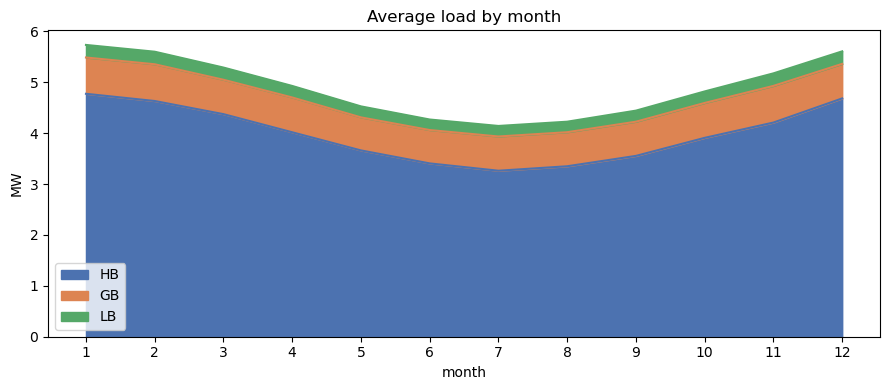

,HB,GB,LB,total
month,,,,
1,4.77,0.71,0.25,5.73
2,4.63,0.72,0.25,5.60
3,4.37,0.68,0.24,5.29
4,4.02,0.68,0.23,4.93
5,3.66,0.65,0.22,4.53
6,3.41,0.66,0.21,4.27
7,3.26,0.67,0.21,4.14
8,3.35,0.67,0.21,4.23
9,3.55,0.67,0.22,4.44


In [8]:
monthly = load.groupby("month")[["HB", "GB", "LB", "total"]].mean() * 4
ax = monthly[["HB", "GB", "LB"]].plot.area(figsize=(9, 4), color=C)
ax.set_xlabel("month"); ax.set_ylabel("MW"); ax.set_xticks(range(1, 13))
ax.set_title("Average load by month")
plt.tight_layout(); plt.show()
monthly.round(2)

## Interpretation

**Scaling.** The three `*_normalized_kwh` columns are pure shape curves with a fixed annual sum
(1,000,000 kWh). For each group a single multiplicative factor $E_p / \sum s_p$ (here 35.00, 6.00
and 2.00) lifts the curve to the required annual energy without changing its time shape. There is no
free parameter and no calibration - the shape comes entirely from the SLP.

**Reconciliation.** $\sum_t L_{p,t}$ equals $E_p$ exactly (35,000.00 / 6,000.00 / 2,000.00 MWh) and
43,000.00 MWh in total; the residual difference is floating-point noise ($<10^{-6}$). The forecast is
energetically consistent with the customer table. Average portfolio power is 4.90 MW and the total
load stays between 1.68 MW and 10.40 MW.

**Customer mix -> total shape.** Households account for **81.40 %** of the energy, so the portfolio
load follows the household shape almost entirely: an evening peak around 19-20h (about 7.26 MW at
19h), an overnight trough (about 1.93 MW at 03h), and **strong seasonality** (HB 4.77 MW in January
vs. 3.26 MW in July, +46 %). The weekly contrast is weak and even slightly inverted - HB load is
**higher** on weekends (4.17 vs. 3.91 MW) because households are home more. General commercial
(13.95 %) provides the only classic weekday block (0.75 MW on weekdays vs. 0.52 MW on weekends,
-31 %) but is too small to turn the overall profile. Agriculture (4.65 %) is almost flat.

**Implications for Base/Peak futures.** The baseload (4.90 MW on average, never below 1.68 MW) argues
for a large **Base** component. A **Peak** product (Mon-Fri 08-20) only partly fits: the HB evening
peak runs past 20h and weekends are not reduced, so only the GB share falls cleanly into the peak
window -> the Peak position stays small. The strong seasonality is the main argument for staggering
the hedge **by quarter** (more MW in Q1/Q4) rather than flat across the year - Stage 2/3 picks this
up again.

## Save intermediate result (input for Stage 2)

In [9]:
out = load[["HB", "GB", "LB", "total"]].copy()
out.insert(0, "timestamp_utc", slp["timestamp_utc"].values)
out.to_csv(f"{DATA}/forecast_load.csv", index=False)
print("saved:", f"{DATA}/forecast_load.csv", out.shape)
out.head()

saved: ../../data/forecast_load.csv (35136, 5)


,timestamp_utc,HB,GB,LB,total
0,2023-12-31T23:00:00Z,0.95,0.09,0.03,1.08
1,2023-12-31T23:15:00Z,0.88,0.09,0.03,1.00
2,2023-12-31T23:30:00Z,0.81,0.09,0.03,0.93
3,2023-12-31T23:45:00Z,0.75,0.08,0.03,0.87
4,2024-01-01T00:00:00Z,0.69,0.08,0.03,0.80
